<a href="https://colab.research.google.com/github/qiyuriko/ICT304-Assignment1/blob/main/ICT304_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

zip_path = "/content/bird_data.zip"
extract_path = "/content/bird_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("zip over")

zip over


In [4]:
import os

data_path = "/content/bird_data"

print("Folder contents：")
print(os.listdir(data_path))

print("\nNumber of images in each folder：")
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)

    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(folder, ":", len(files))

Folder contents：
['dataset']

Number of images in each folder：
dataset : 2


In [5]:
dataset_path = "/content/bird_data/dataset"

print(os.listdir(dataset_path))

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

['089.Hooded_Merganser', '087.Mallard']
089.Hooded_Merganser : 60
087.Mallard : 60


In [6]:
from PIL import Image
import os

dataset_path = "/content/bird_data/dataset"

corrupted_files = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)

print("Corrupted images:", len(corrupted_files))

if corrupted_files:
    for file in corrupted_files:
        print(file)
else:
    print("No corrupted images found.")

Corrupted images: 0
No corrupted images found.


In [7]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/content/bird_data/dataset"

sizes = []
modes = []
formats = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            with Image.open(file_path) as img:
                sizes.append(img.size)
                modes.append(img.mode)
                formats.append(img.format)

print("Image sizes:", Counter(sizes))
print("Color modes:", Counter(modes))
print("Image formats:", Counter(formats))

Image sizes: Counter({(500, 375): 21, (500, 333): 18, (500, 332): 6, (500, 334): 5, (500, 400): 4, (500, 330): 3, (500, 318): 2, (333, 500): 2, (500, 500): 2, (500, 340): 2, (500, 376): 2, (500, 346): 1, (500, 379): 1, (500, 320): 1, (500, 302): 1, (500, 337): 1, (500, 286): 1, (500, 338): 1, (400, 234): 1, (484, 460): 1, (432, 288): 1, (500, 307): 1, (400, 400): 1, (400, 265): 1, (500, 374): 1, (447, 500): 1, (500, 240): 1, (450, 339): 1, (500, 344): 1, (400, 300): 1, (500, 335): 1, (500, 312): 1, (500, 371): 1, (500, 348): 1, (428, 500): 1, (500, 357): 1, (450, 300): 1, (500, 342): 1, (372, 500): 1, (400, 267): 1, (500, 300): 1, (500, 463): 1, (485, 500): 1, (500, 272): 1, (500, 363): 1, (500, 359): 1, (500, 434): 1, (500, 305): 1, (500, 399): 1, (450, 403): 1, (500, 361): 1, (500, 354): 1, (417, 500): 1, (500, 385): 1, (500, 381): 1, (500, 351): 1, (500, 279): 1, (374, 500): 1, (500, 317): 1, (500, 293): 1, (500, 353): 1, (500, 352): 1, (469, 500): 1, (444, 500): 1})
Color modes: Co

In [8]:
from PIL import Image
import os

input_path = "/content/bird_data/dataset"
output_path = "/content/bird_data/preprocessed"

os.makedirs(output_path, exist_ok=True)

target_size = (224, 224)

for folder in os.listdir(input_path):
    folder_path = os.path.join(input_path, folder)

    if os.path.isdir(folder_path):
        new_folder = os.path.join(output_path, folder)
        os.makedirs(new_folder, exist_ok=True)

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            save_path = os.path.join(new_folder, file)

            with Image.open(file_path) as img:
                img = img.convert("RGB")
                img = img.resize(target_size)
                img.save(save_path)

print("Preprocessing completed.")

Preprocessing completed.


In [9]:
from PIL import Image
import os
from collections import Counter

output_path = "/content/bird_data/preprocessed"

sizes = []
modes = []
total = 0

for folder in os.listdir(output_path):
    folder_path = os.path.join(output_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            with Image.open(file_path) as img:
                sizes.append(img.size)
                modes.append(img.mode)
                total += 1

print("Total images:", total)
print("Image sizes:", Counter(sizes))
print("Color modes:", Counter(modes))

Total images: 120
Image sizes: Counter({(224, 224): 120})
Color modes: Counter({'RGB': 120})


In [10]:
import os
import hashlib

data_path = "/content/bird_data/preprocessed"

hash_dict = {}
duplicates = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hash_dict:
                duplicates.append((hash_dict[file_hash], file_path))
            else:
                hash_dict[file_hash] = file_path

print("Duplicate images:", len(duplicates))

for pair in duplicates:
    print(pair)

Duplicate images: 0


Class: 089.Hooded_Merganser


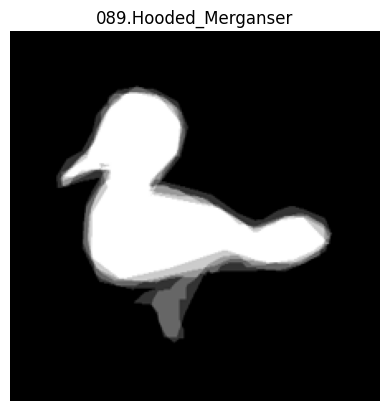

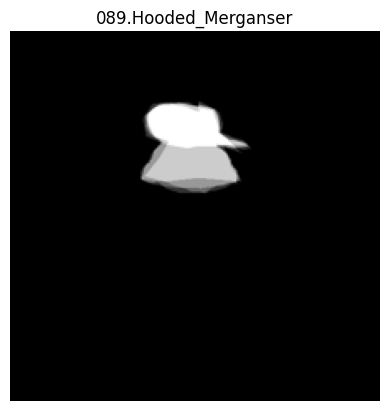

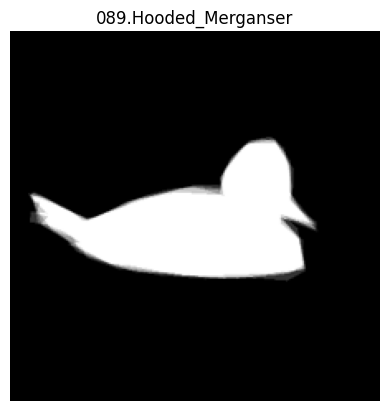

Class: 087.Mallard


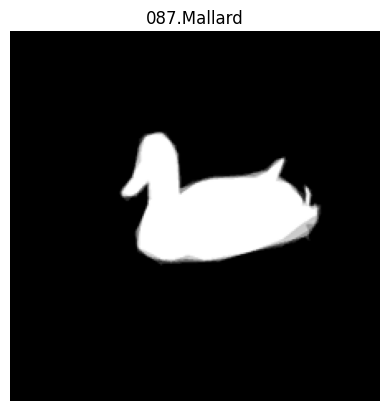

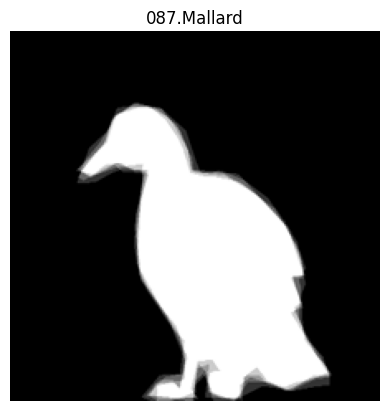

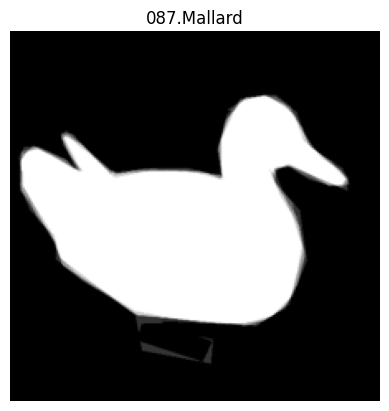

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

data_path = "/content/bird_data/preprocessed"

folders = [f for f in os.listdir(data_path)
           if os.path.isdir(os.path.join(data_path, f))]

for folder in folders:
    folder_path = os.path.join(data_path, folder)
    files = os.listdir(folder_path)

    sample_files = random.sample(files, 3)

    print("Class:", folder)

    for file in sample_files:
        img = Image.open(os.path.join(folder_path, file))

        plt.figure()
        plt.imshow(img)
        plt.title(folder)
        plt.axis("off")
        plt.show()